<a href="https://colab.research.google.com/github/Arrah28/AWS-ML-Financial-Health-Analytics-Project/blob/main/Unsupervised_CC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

#Unsupervised Data Summary

---


In [ ]:
cc_df = pd.read_csv('/content/CC GENERAL.csv')
print ('Print Databases loaded successfully')

Print Databases loaded successfully


In [ ]:
# --- CATEGORICAL DISTRIBUTION (CREDIT CARD) ---
print("\n--- CREDIT CARD CATEGORICAL DATA ---")
print("Total Unique Customers:", cc_df['CUST_ID'].nunique()) #It will only unique and non repetitive cusotmer based on the ID


--- CREDIT CARD CATEGORICAL DATA ---
Total Unique Customers: 8950


In [ ]:
print(cc_df.describe().T) #outputs 8 key features

                                   count         mean          std        min  \
BALANCE                           8950.0  1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904   0.000000   
PURCHASES                         8950.0  1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115   0.000000   
CASH_ADVANCE                      8950.0   978.871112  2097.163877   0.000000   
PURCHASES_FREQUENCY               8950.0     0.490351     0.401371   0.000000   
ONEOFF_PURCHASES_FREQUENCY        8950.0     0.202458     0.298336   0.000000   
PURCHASES_INSTALLMENTS_FREQUENCY  8950.0     0.364437     0.397448   0.000000   
CASH_ADVANCE_FREQUENCY            8950.0     0.135144     0.200121   0.000000   
CASH_ADVANCE_TRX                  8950.0     3.248827     6.824647   0.000000   
PURCHASES_TRX               

One key difference to note between the supervised and unsupervised datasets is that in the unsupervised we do not have a target column, which is essentially the answer column. Instead for unsupervised we have a range of columns which need to be analysed, corelations need to be found and then clustered (grouped).
Now the output shows us the 8 different numerical characteristics of the dataset.

They key ones for us being that :
* Mean and median together - if the mean is much higher than the Median, this means that there is major outlier or in the context of this dataset, there are big spenders pulling the total average of the dataset up.
* Max and Min -Simply tell us the smallest and most extreme value in our dataset.
* Std - Tells us if customers are mostly similar (low Std) or highly different (high Std).

The reason why these characteristics are crucial is because this dataset our goal is to cluster the data (k means). The model will do this clustering based on mathematical calculation which will calculate the "Distance" between customers and group each customer to its closest cluster.



#In depth:

---

In the dataset if we look the purchase_frequency value the values are within 0 and 1 and the biggest difference within the dataset is approximately 0.5 which is considerably small. What this will result in the models thinking the numerical differences like £100 difference in balance between individuals is 100 times more important than the frequency difference.

So, the data analysis and prediction will not be equal nor fair. The way to overcome this is to scale all the data to 0.

Now, if we look at the median value when it comes to purchases, we see that the:

* 50% only spends £361
* 75% spends £1,110
* One person spent £49,039

The data is very heavily right skewed due to this extremely high figure. Now what will happen is if we don’t scale our data these few big spenders will end up in their own clusters, and the other 8000 people will be lumped into one giant individual cluster which is not what we want at all.

Now, another thing to note is that there is customer data missing. Looking at the count column which gives us a total amount of data within each feature we can see that:

* Most features have 8,950 rows.

* credit limit has 8949 (1 person is missing a limit)

* minimum payments have 8637 (313 people are missing payments)

The reason why this is crucial is because we cannot calculate the distance when it will come to clustering the data if there are holes in customer information so what we will do is SimpleImpute with the median value for those specific numerical features.


In [ ]:
# --- CREDIT CARD DATASET SUMMARY ---
print("--- CREDIT CARD DATASET OVERVIEW ---")
print(f"Instances (Rows): {cc_df.shape[0]}, Features (Columns): {cc_df.shape[1]}")
print("\nMissing Values per Feature:")
print(cc_df.isnull().sum())

--- CREDIT CARD DATASET OVERVIEW ---
Instances (Rows): 8950, Features (Columns): 18

Missing Values per Feature:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64



This is a clearer view of the 313 missing values in minimum payments and the 1 in credit_limit. One key thing to notice is that some features might be repetitive in the sense of their output definition. So what the data tells us for example, PURCHASES and PURCHASES_TRX (which simply refers to Transactions).




In [ ]:
#Mean , Mediam and Standard deviations
print("\n--- CREDIT CARD NUMERICAL MEASURES ---")
stats_cc = cc_df[['BALANCE', 'PURCHASES']].agg(['mean', 'median', 'std']) #.agg will join the  data instead of just giving one stat it will give three at once for the columns  selected
print(stats_cc)


--- CREDIT CARD NUMERICAL MEASURES ---
            BALANCE    PURCHASES
mean    1564.474828  1003.204834
median   873.385231   361.280000
std     2081.531879  2136.634782


Identifying these 3 values, the mean, median and std is crucial in unsupervised learning as it will help us find Skewness. If data is skewed, which it is as we have already seen form the outlying big spenders, then centre of our clusters will be pulled toward the extreme outliers.

Now, remembering that the mean is a key value which is easily influenced by outliers. And the median is the most middle value of the numerical in the set.

So:
* BALANCE: The Mean is £1564 which is nearly double the Median of £873

* PURCHASES: The Mean is £1003 is nearly triple the Median of £361

This overall already tells us that the data is very right skewered. As the average spending of a typical (median) customers is £361 but due to the big spenders are resulting in the mean being shown as £1003

Now another final factor is that eh std is extremely large. A high Std relative to the Mean tells us that the data is very mixed and spread out.


##Visualisations: Histogram, Boxplot and Scatter Plot

---



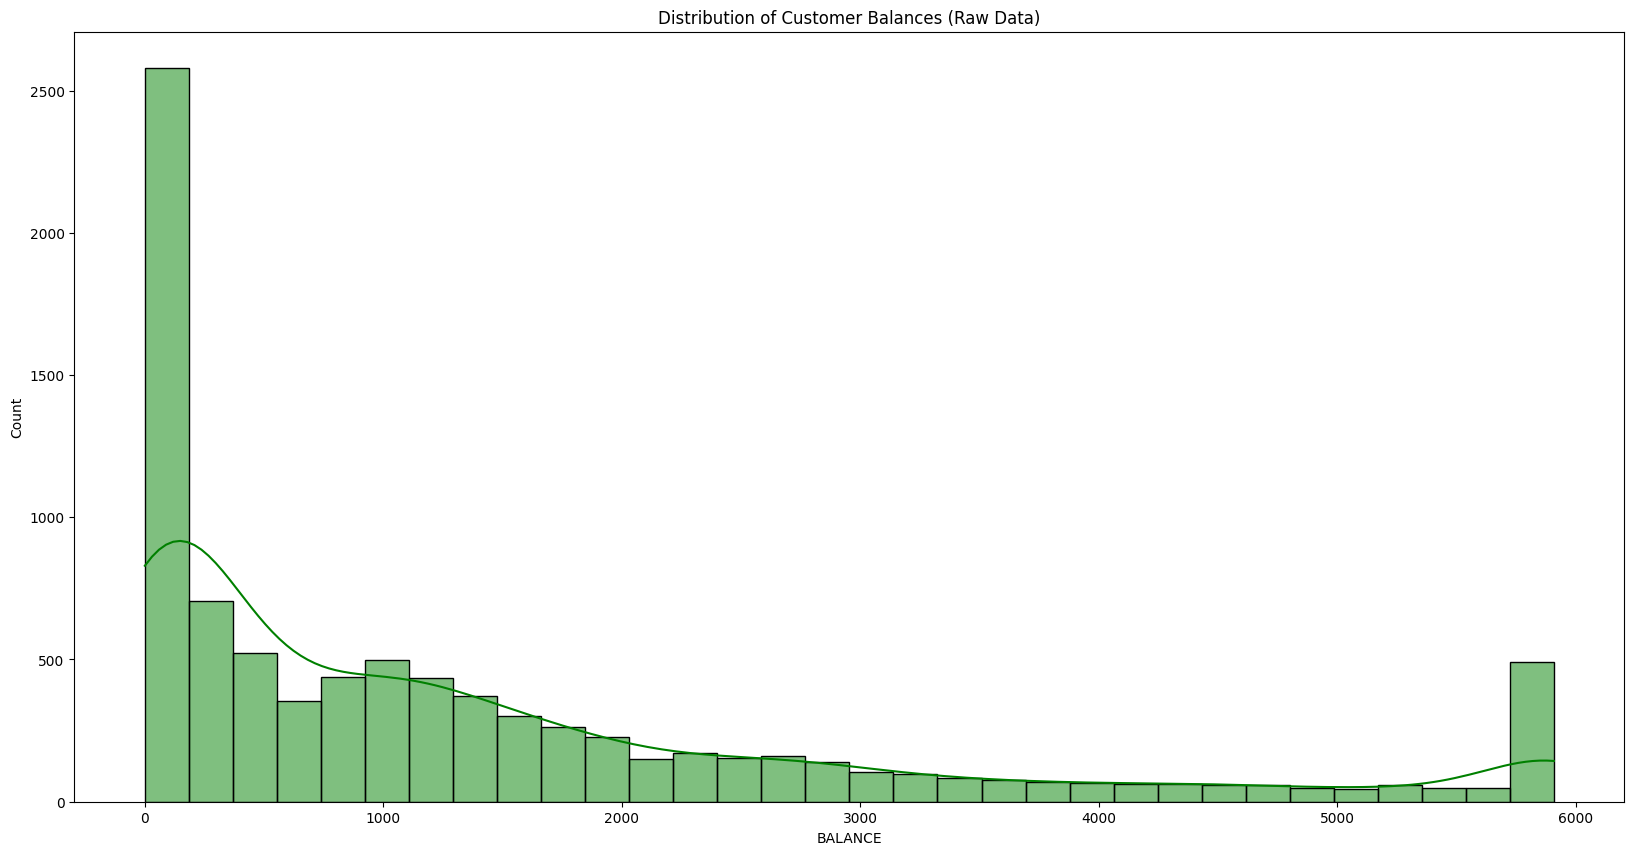

In [24]:
# Histogram used to  Check for "Skewness" in this financial data.
plt.figure(figsize=(20, 10))
sns.histplot(cc_df['BALANCE'], kde=True, color='green')
plt.title('Distribution of Customer Balances (Raw Data)')
plt.show()
#the code above SORTS, BINS, provides a frequency count and the KDE

This histogram is visual proof in relation to customers spending and that they are not all the same, which is exactly why clustering is required.

The Tall bar on the left side represents the vast majority of the 8950 customers who have very low balances which is between £0 and £1000

The Long and same height bars on the right Side that stretch all the way to £19,000. These are your high debt or high usage customers

The Green KDE Line simplifies the visualisation trend of the bars by simplifying the overall "flow"



#In depth :

---
Futher down the development of the model we will use K-Means clustering which for effiency prefers data that is Symmetric making it easier to analyse and group. Currently the data is  stretched out due to the few but large spenderswhich pull the cluster centers far away from the average person

This graph helps us understand why StandardScaler is required as feature like balance which range from 0 to 19,000 will overpower features like Purchases Frequency which only has two values, 0 to 1.

As shown in the grpah he highest bar is right at the beginning covering the vlaues betwen £0-£500. Telling us that tells us that banks primary business is people who use their cards lightly or pay them off quickly within that spending range.

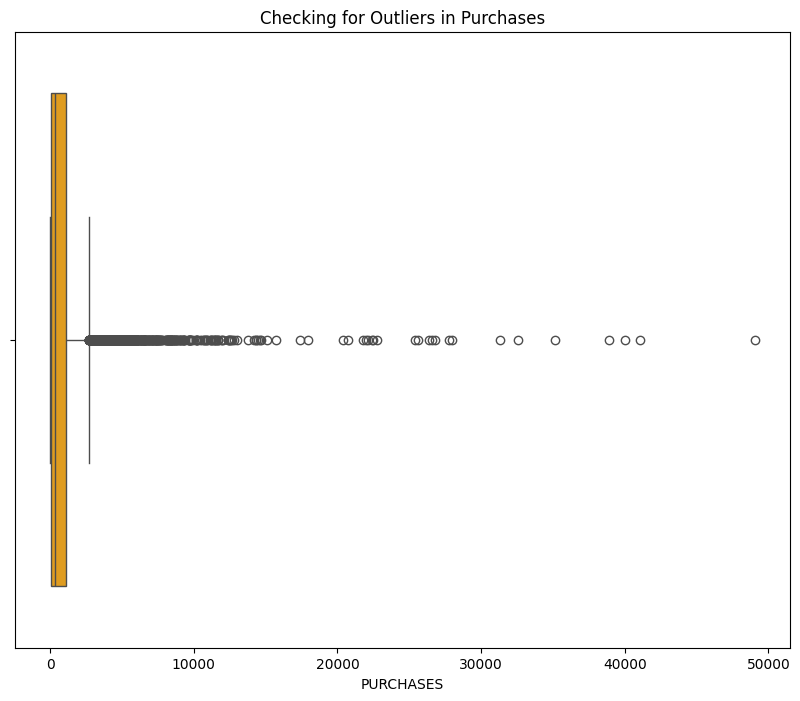

In [ ]:
# A boxplot to Check for financial "Outliers" and it will help with the applicaiton explanation of standard scaling later.
plt.figure(figsize=(10, 8))
sns.boxplot(x=cc_df['PURCHASES'], color='orange')
plt.title('Checking for Outliers in Purchases')
plt.show()

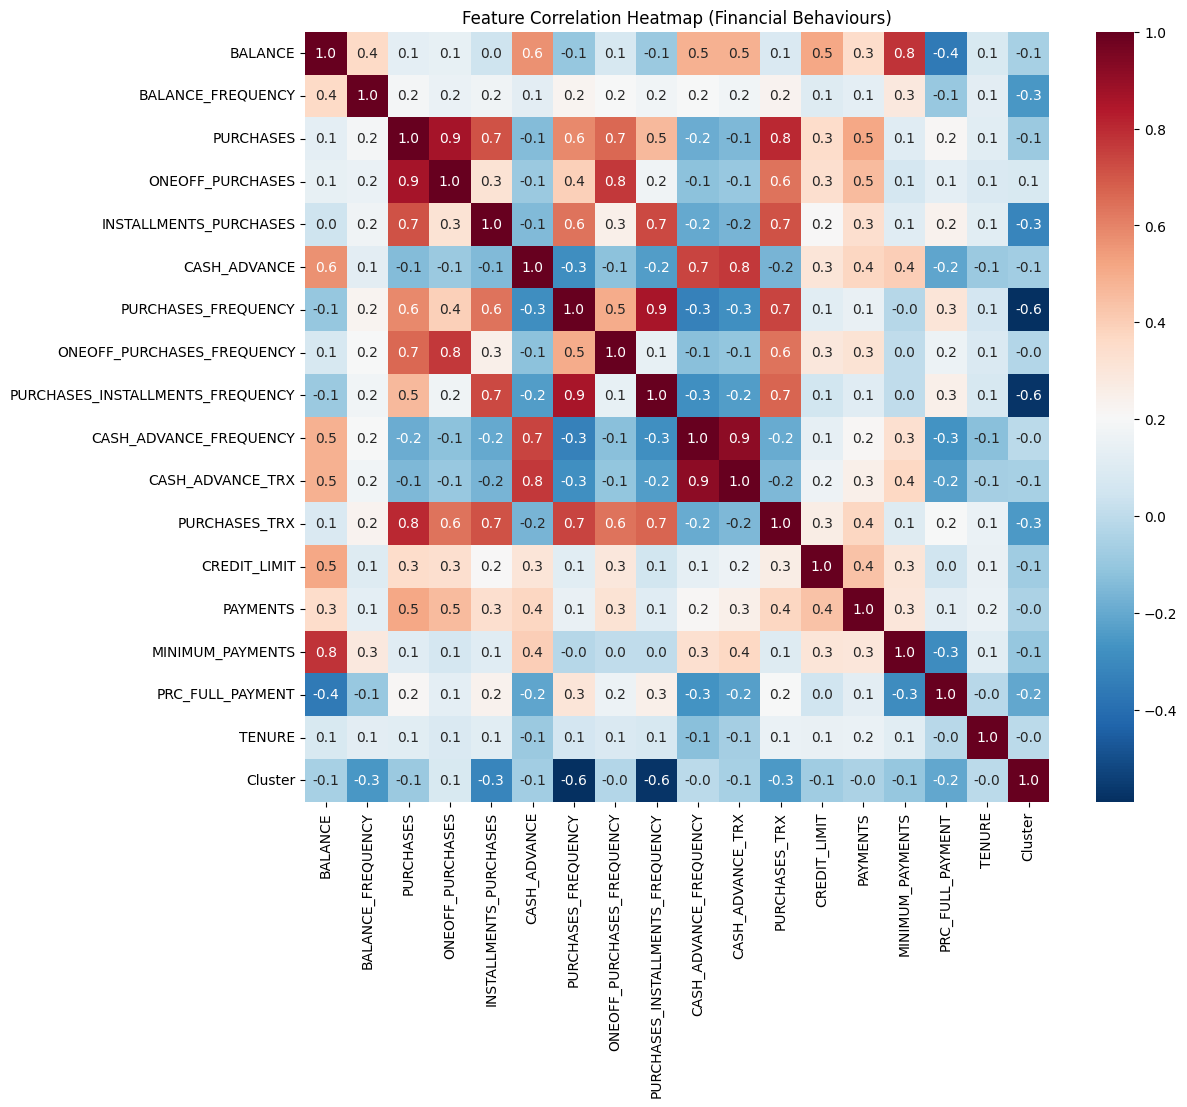

In [ ]:
plt.figure(figsize=(12, 10))
# Dropping CUST_ID as it's non-numeric
sns.heatmap(cc_df.drop('CUST_ID', axis=1).corr(), annot=True, fmt=".1f", cmap='RdBu_r')
plt.title('Feature Correlation Heatmap (Financial Behaviours)')
plt.show()

#Data Pre-processing

---


In [ ]:
#this will fill the missing 'MINIMUM_PAYMENTS' and 'CREDIT_LIMIT' with the mean value
imputer = SimpleImputer(strategy='median')
cc_df['MINIMUM_PAYMENTS'] = imputer.fit_transform(cc_df[['MINIMUM_PAYMENTS']])
cc_df['CREDIT_LIMIT'] = imputer.fit_transform(cc_df[['CREDIT_LIMIT']])

In [ ]:
#This will drop the the ID column as its not a behaviour , just extra noise
numeric_cols = cc_df.drop('CUST_ID', axis=1).columns
cc_df[numeric_cols] = cc_df[numeric_cols].clip(upper=cc_df[numeric_cols].quantile(0.95), axis=1)

In [ ]:
# Standardise the numerical value so the all hav an average of 0 , making the
# data amore centered and comperable
scaler = StandardScaler()

In [ ]:
# Convert back to a DataFrame for easier viewing rahter then leaving it as array
cc_scaled = scaler.fit_transform(cc_df.drop('CUST_ID', axis=1))

In [ ]:
print("Variable 'cc_scaled' created successfully!")

Variable 'cc_scaled' created successfully!


#Hierarchical Clustering

---



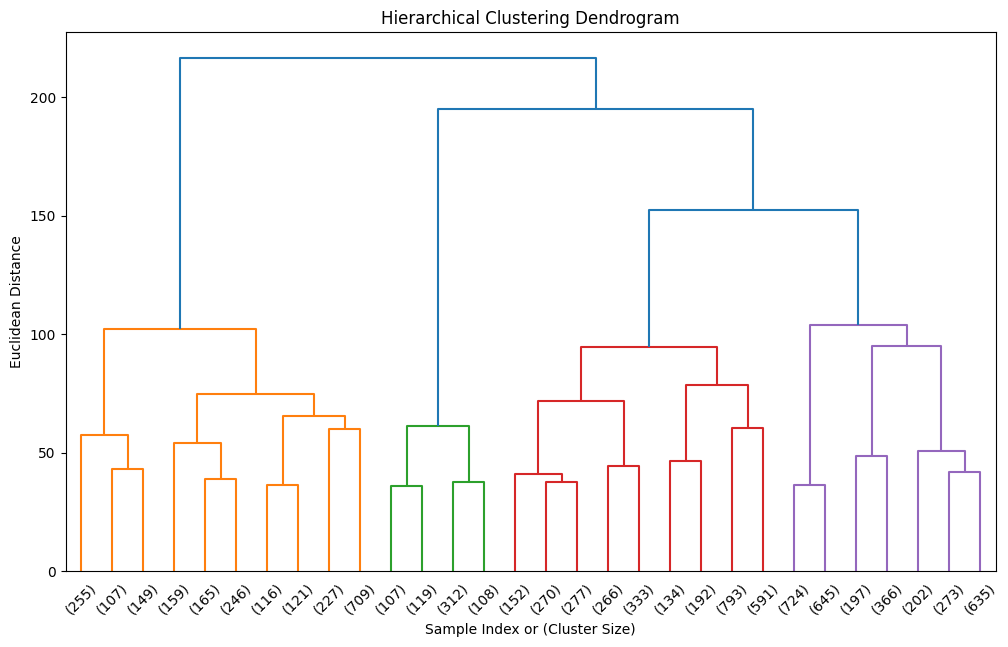

In [ ]:
Z = linkage(cc_scaled, method='ward')

plt.figure(figsize=(12, 7))
dendrogram(Z, truncate_mode='lastp', p=30) # Showing the last 30 merges for clarity
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index or (Cluster Size)")
plt.ylabel("Euclidean Distance")
plt.show()

#Learning Models - K means  and PCA

---

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10).fit(cc_scaled)
    wcss.append(kmeans.inertia_)


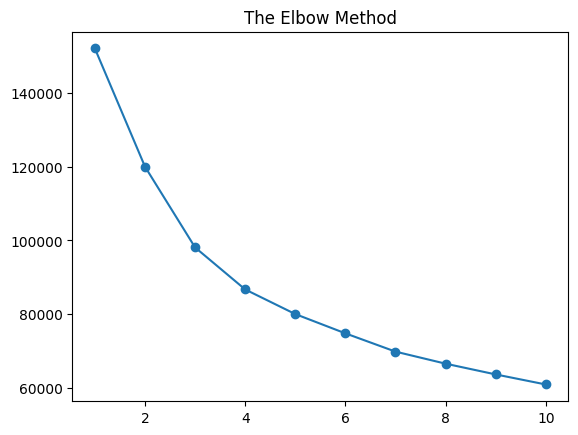

In [ ]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.show()

In [ ]:
kmeans_model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
cc_df['Cluster'] = kmeans_model.fit_predict(cc_scaled)

In [ ]:
pca = PCA(n_components=2)
cc_pca = pca.fit_transform(cc_scaled)

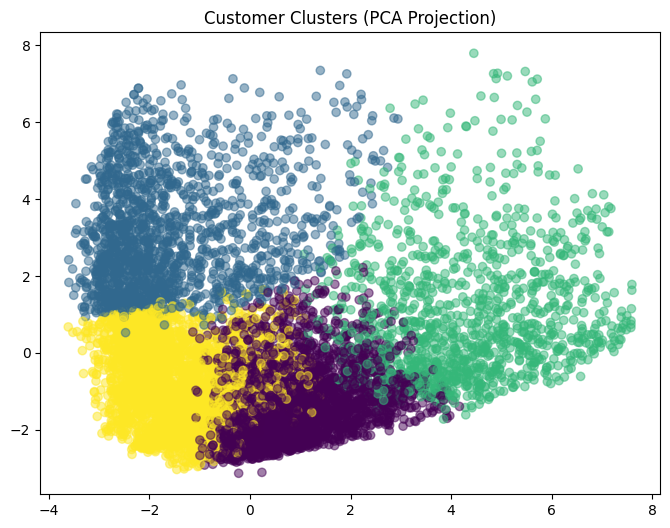

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(cc_pca[:, 0], cc_pca[:, 1], c=cc_df['Cluster'], cmap='viridis', alpha=0.5)
plt.title('Customer Clusters (PCA Projection)')
plt.show()